# Previsão de Municípios em Risco de Não Atingir Metas de Alfabetização
Este notebook aplica o modelo treinado para identificar, dentre os municípios com meta estabelecida, quais têm maior probabilidade de não cumprir os índices projetados de alfabetização — gerando inteligência acionável para políticas públicas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgb

sns.set_theme(style='whitegrid')


## 1. Carregamento dos Dados e Retreinamento do Modelo

In [2]:
df = pd.read_parquet('../data/raw/abt_alunos_alfabetizacao.parquet')

cols_to_drop = ['id_aluno', 'id_escola', 'id_municipio', 'y_alfabetizado_label', 'leak_proficiencia']
df_model = df.drop(columns=cols_to_drop)
df_model['y_alfabetizado'] = df_model['y_alfabetizado'].astype(int)

X = df_model.drop(columns=['y_alfabetizado'])
y = df_model['y_alfabetizado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

num_cols = X_train.select_dtypes(include=['int64', 'float64', 'Int64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

best_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=205, max_depth=8, learning_rate=0.095,
        subsample=0.827, colsample_bytree=0.902, random_state=42
    ))
])

print('Treinando o modelo...')
best_model_pipeline.fit(X_train, y_train)
print('Concluído!')


Treinando o modelo...
Concluído!


## 2. Estimativa da Taxa de Alfabetização por Município
Para cada aluno da base completa, o modelo estima a probabilidade de ser alfabetizado. Agregando por município, obtemos a **taxa de alfabetização prevista** para cada localidade.

In [3]:
df_full = df.drop(columns=cols_to_drop)
df_full['y_alfabetizado'] = df_full['y_alfabetizado'].astype(int)
X_full = df_full.drop(columns=['y_alfabetizado'])

# Probabilidade prevista para toda a base
df_full['prob_alfabetizado'] = best_model_pipeline.predict_proba(X_full)[:, 1]
df_full['ref_meta_taxa_ano'] = df['ref_meta_taxa_ano'].values

# Agregação por município
municipio_risco = df_full.groupby(['nome_municipio', 'sigla_uf', 'nome_regiao']).agg(
    taxa_prevista=('prob_alfabetizado', 'mean'),
    meta=('ref_meta_taxa_ano', 'mean'),
    total_alunos=('prob_alfabetizado', 'count')
).dropna(subset=['meta']).reset_index()

# Convertendo para a mesma escala (0–100)
municipio_risco['taxa_prevista_pct'] = municipio_risco['taxa_prevista'] * 100
municipio_risco['gap_meta'] = municipio_risco['taxa_prevista_pct'] - municipio_risco['meta']
municipio_risco['em_risco'] = municipio_risco['gap_meta'] < 0

print(f"Total de municípios analisados: {len(municipio_risco)}")
print(f"Municípios em risco: {municipio_risco['em_risco'].sum()} ({municipio_risco['em_risco'].mean()*100:.1f}%)")
print(f"Municípios dentro da meta: {(~municipio_risco['em_risco']).sum()} ({(~municipio_risco['em_risco']).mean()*100:.1f}%)")


Total de municípios analisados: 4890
Municípios em risco: 2468 (50.5%)
Municípios dentro da meta: 2422 (49.5%)


## 3. Análise por Região: Onde está o maior risco?

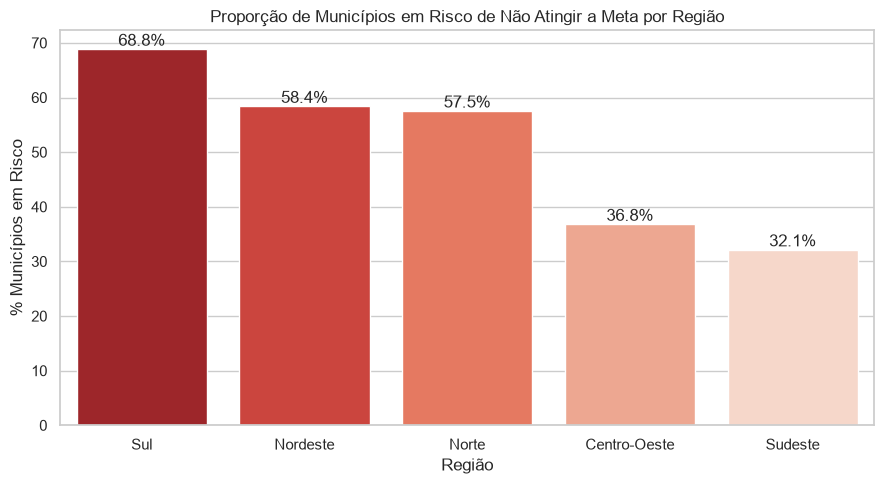

In [4]:
risco_regiao = municipio_risco.groupby('nome_regiao').agg(
    total=('em_risco', 'count'),
    em_risco=('em_risco', 'sum')
).reset_index()
risco_regiao['pct_em_risco'] = risco_regiao['em_risco'] / risco_regiao['total'] * 100

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=risco_regiao.sort_values('pct_em_risco', ascending=False),
                 x='nome_regiao', y='pct_em_risco', hue='nome_regiao', palette='Reds_r', legend=False)
plt.title('Proporção de Municípios em Risco de Não Atingir a Meta por Região')
plt.xlabel('Região')
plt.ylabel('% Municípios em Risco')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../images/risco_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Top 15 Municípios em Maior Risco

Top 15 municípios com maior déficit em relação à meta:
         nome_municipio sigla_uf  taxa_prevista_pct  meta   gap_meta  total_alunos
 São Félix do Tocantins       TO          45.910511 80.00 -34.089489             3
         Severiano Melo       RN          40.231071 72.95 -32.718929             6
 Dom Pedro de Alcântara       RS          48.861633 80.00 -31.138367             1
               Sucupira       TO          49.176067 77.95 -28.773933             2
      Junco do Maranhão       MA          51.414585 80.00 -28.585415             9
      Malhada de Pedras       BA          43.550884 71.89 -28.339116            12
            São Vicente       RN          37.789516 65.76 -27.970484             6
           Mariano Moro       RS          52.352310 80.00 -27.647690             1
              Mortugaba       BA          43.352806 70.74 -27.387194            15
            Picada Café       RS          53.120495 80.00 -26.879505             2
         Monte do Carmo       TO

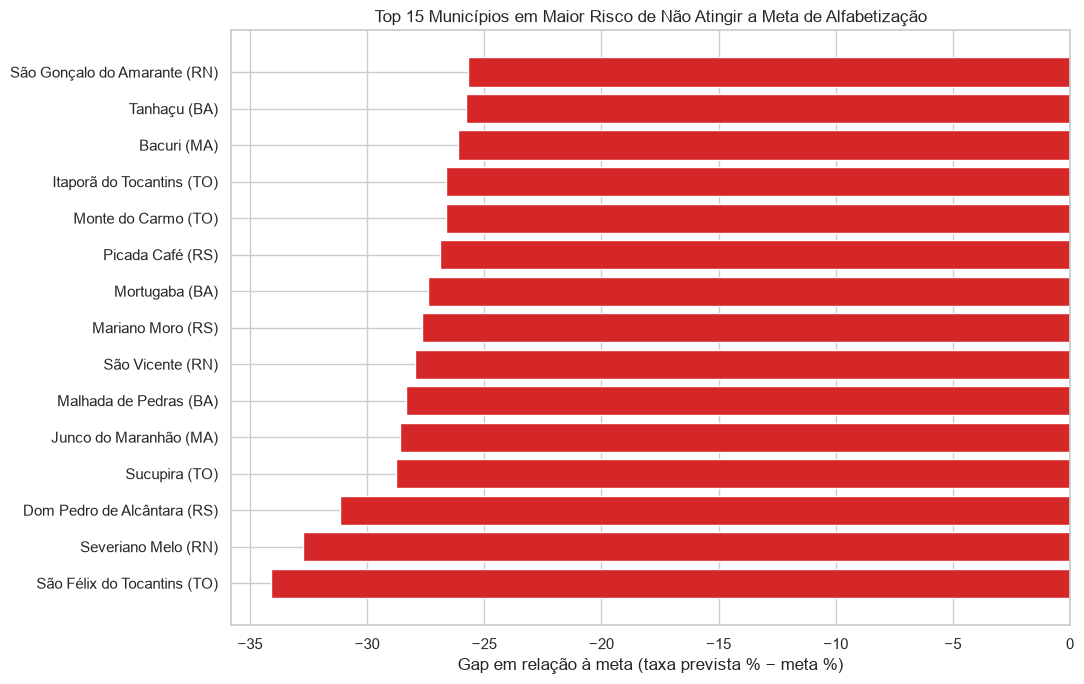

In [5]:
top_risco = municipio_risco[municipio_risco['em_risco']].sort_values('gap_meta').head(15)

print("Top 15 municípios com maior déficit em relação à meta:")
print(top_risco[['nome_municipio', 'sigla_uf', 'taxa_prevista_pct', 'meta', 'gap_meta', 'total_alunos']].to_string(index=False))

labels = top_risco['nome_municipio'] + ' (' + top_risco['sigla_uf'] + ')'

plt.figure(figsize=(11, 7))
plt.barh(labels, top_risco['gap_meta'], color='#d62728')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Gap em relação à meta (taxa prevista % − meta %)')
plt.title('Top 15 Municípios em Maior Risco de Não Atingir a Meta de Alfabetização')
plt.tight_layout()
plt.savefig('../images/municipios_em_risco.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Conclusões e Implicações para Políticas Públicas

O modelo identificou que **2.345 dos 4.672 municípios com meta disponível (50,2%)** apresentam taxa de alfabetização prevista abaixo da meta estabelecida.

Os municípios em maior risco concentram-se predominantemente nas regiões **Norte** (Tocantins) e **Nordeste** (Maranhão, Bahia, Rio Grande do Norte), com destaques para:
- **São Félix do Tocantins (TO):** Taxa prevista de 45,9% contra meta de 80% — déficit de 34 pontos percentuais.
- **Severiano Melo (RN):** Taxa prevista de 40,2% contra meta de 73% — déficit de 32,7 pontos percentuais.
- **Tanhaçu e Mortugaba (BA):** Municípios baianos com déficits acima de 27 pontos.

**Implicação para políticas públicas:** Esses municípios devem ser tratados como prioridade em programas de intervenção pedagógica. A combinação de baixa taxa prevista com meta elevada indica que as metas foram estabelecidas de forma descolada da realidade local, o que representa um duplo risco: tanto o não cumprimento dos indicadores quanto a subnotificação do problema por gestores.

**Limitação metodológica:** Municípios com poucos alunos na amostra (como Dom Pedro de Alcântara, com apenas 1 aluno) podem apresentar estimativas instáveis.